## Goal: To check if the model initially designed for a given location can be used for other locations when using relative information

### This is all about performance on the test sets

In [2]:
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
import tensorflow as tf                                                                 # type: ignore
import matplotlib as mpl                                                                # type: ignore
from joblib import load                                                                 # type: ignore
import sys
sys.path.insert(1, "/home/mendrika/mendrika-phd/codes/nflics")
import nflics  

2024-10-24 12:06:12.855662: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-24 12:06:12.860772: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-24 12:06:12.921695: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-24 12:06:14.502227: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
font = {'family' : 'serif',
        'weight' : 'normal',
        'size'   : 9}

mpl.rc('font', **font)

axis_font = {'family': 'serif',
             'color':  'black',
             'weight': 'normal',
             'size': 12,
            }

### Importing dataset

These data were created using the same method and use the same padding method especially for relative lats and lons.

In [4]:
test_data_Bamako = pd.read_csv("./test-data-Bamako.csv", index_col=False)
test_data_Dakar = pd.read_csv("./test-data-Dakar.csv", index_col=False)
test_data_Selibaby = pd.read_csv("./test-data-Selibaby.csv", index_col=False)

In [5]:
test_data_Dakar

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size4,size5,ds1,ds2,ds3,ds4,ds5,Cb_Dakar_t1,Cb_Dakar_t3,Cb_Dakar_t6
0,2020,6,1,0,0,11.32,-16.08,10.11,-15.77,11.370000,...,0.0,0.0,121.46,123.66,167.44,520.0,520.0,0.0,0.0,0.0
1,2020,6,1,0,15,10.20,-15.86,10.02,-14.11,14.716677,...,0.0,0.0,162.78,192.82,520.00,520.0,520.0,0.0,0.0,0.0
2,2020,6,1,0,30,10.20,-17.07,10.06,-14.11,10.240000,...,0.0,0.0,158.00,161.05,191.97,520.0,520.0,0.0,0.0,0.0
3,2020,6,1,1,0,10.38,-16.08,10.11,-17.12,10.650000,...,0.0,0.0,153.63,155.98,161.00,520.0,520.0,0.0,0.0,0.0
4,2020,6,1,1,15,10.15,-17.21,10.38,-16.17,10.780000,...,0.0,0.0,149.05,154.35,160.03,520.0,520.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20224,2022,9,30,3,45,10.83,-12.98,12.00,-13.25,14.716677,...,0.0,0.0,164.76,195.97,520.00,520.0,520.0,0.0,0.0,0.0
20225,2022,9,30,4,0,10.87,-13.07,11.95,-13.34,14.716677,...,0.0,0.0,162.86,192.42,520.00,520.0,520.0,0.0,0.0,0.0
20226,2022,9,30,4,15,10.92,-13.16,11.95,-13.43,14.716677,...,0.0,0.0,160.42,189.55,520.00,520.0,520.0,0.0,0.0,0.0
20227,2022,9,30,4,30,10.87,-13.21,11.91,-13.52,14.716677,...,0.0,0.0,159.20,190.22,520.00,520.0,520.0,0.0,0.0,0.0


#### Taking the true target at lead time 1 and 3 hours

In [6]:
y_Bamako_t1 = test_data_Bamako["Cb_Bamako_t1"]
y_Bamako_t3 = test_data_Bamako["Cb_Bamako_t3"]

y_Dakar_t1 = test_data_Dakar["Cb_Dakar_t1"]
y_Dakar_t3 = test_data_Dakar["Cb_Dakar_t3"]

y_Selibaby_t1 = test_data_Selibaby["Cb_Selibaby_t1"]
y_Selibaby_t3 = test_data_Selibaby["Cb_Selibaby_t3"]

#### Input 

In [7]:
def get_field(location, lead_time):
    target_index = f"Cb_{location}_t{lead_time}"    
    t0 = "year,month,day,hour,minute,"
    location = ""
    wavelet_power = ""
    storm_size = ""
    distance = ""
    for i in range(1,6):
        location += f"lat{i},lon{i},"
        wavelet_power += f"wp{i},"
        distance += f"ds{i},"
        storm_size += f"size{i},"
    features = t0 + location + wavelet_power + storm_size + distance
    field =  features + target_index    
    return field.split(',')

In [8]:
t0 = "year,month,day,hour,minute,"
location = ""
wavelet_power = ""
storm_size = ""
distance = ""
for i in range(1,6):
    location += f"lat{i},lon{i},"
    wavelet_power += f"wp{i},"
    distance += f"ds{i},"
    storm_size += f"size{i},"
features = (t0 + location + wavelet_power + storm_size + distance[:-1]).split(',')

In [9]:
test_data_Bamako_features = test_data_Bamako[features]
test_data_Dakar_features = test_data_Dakar[features]
test_data_Selibaby_features = test_data_Selibaby[features]

In [10]:
original_test_data_Bamako_features = test_data_Bamako_features.copy()
original_test_data_Dakar_features = test_data_Dakar_features.copy()
original_test_data_Selibaby_features = test_data_Selibaby_features.copy()

### Transforming latitude and longitude to relative latitude and relative longitude

In [11]:
def transform_to_relative_latlton(df, location_lat, location_lon):
    df_copy = df.copy()
    for i in range(5):
        df_copy.loc[: ,f"lat{i+1}"] = df_copy[f"lat{i+1}"] - location_lat
        df_copy.loc[: ,f"lon{i+1}"] = df_copy[f"lon{i+1}"] - location_lon
    return df_copy

#### Lat-lon of different cities in West Africa

In [12]:
Bamako_lat, Bamako_lon = 12.6392, -8.0029
Dakar_lat, Dakar_lon = 14.716677, -17.467686
Selibaby_lat, Selibaby_lon = 15.1506, -12.1804

In [13]:
test_data_Bamako_relative_features = transform_to_relative_latlton(test_data_Bamako_features, Bamako_lat, Bamako_lon)
test_data_Dakar_relative_features = transform_to_relative_latlton(test_data_Dakar_features, Dakar_lat, Dakar_lon)
test_data_Selibaby_relative_features = transform_to_relative_latlton(test_data_Selibaby_features, Selibaby_lat, Selibaby_lon)

In [14]:
test_data_Bamako_features

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size1,size2,size3,size4,size5,ds1,ds2,ds3,ds4,ds5
0,2020,6,1,16,15,10.56,-0.54,17.52,-7.05,12.6392,...,12600,25550,0,0.0,0.0,174.64,277.06,520.00,520.00,520.00
1,2020,6,1,16,45,11.28,-1.53,17.70,-7.05,12.6392,...,3050,20700,0,0.0,0.0,180.49,235.93,520.00,520.00,520.00
2,2020,6,1,17,15,16.71,-7.01,12.58,-1.80,12.6700,...,19025,375,9975,9975.0,19025.0,147.53,188.30,215.01,220.01,222.01
3,2020,6,1,17,30,10.33,-3.42,16.80,-6.97,11.3700,...,9300,9300,30950,9300.0,0.0,150.96,181.57,214.06,227.50,520.00
4,2020,6,1,17,45,10.29,-3.42,11.37,-1.84,16.8500,...,13850,2675,9600,13850.0,0.0,152.61,182.02,219.01,224.56,520.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17549,2022,9,30,16,45,12.31,-8.45,15.41,-5.75,14.8700,...,4650,23675,23675,750.0,9825.0,20.81,122.02,127.66,155.47,156.35
17550,2022,9,30,17,0,12.31,-8.49,14.87,-5.35,15.5000,...,2125,1925,6025,28425.0,25150.0,21.63,83.45,123.69,132.65,152.90
17551,2022,9,30,17,15,12.31,-8.54,15.14,-5.89,14.4200,...,7425,3525,24475,575.0,26200.0,23.32,83.63,117.59,140.39,146.24
17552,2022,9,30,17,30,12.31,-8.58,15.50,-6.07,14.7800,...,7525,5400,15250,7550.0,28350.0,24.19,95.59,115.62,123.22,140.70


In [15]:
test_data_Bamako_relative_features

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size1,size2,size3,size4,size5,ds1,ds2,ds3,ds4,ds5
0,2020,6,1,16,15,-2.0792,7.4629,4.8808,0.9529,0.0000,...,12600,25550,0,0.0,0.0,174.64,277.06,520.00,520.00,520.00
1,2020,6,1,16,45,-1.3592,6.4729,5.0608,0.9529,0.0000,...,3050,20700,0,0.0,0.0,180.49,235.93,520.00,520.00,520.00
2,2020,6,1,17,15,4.0708,0.9929,-0.0592,6.2029,0.0308,...,19025,375,9975,9975.0,19025.0,147.53,188.30,215.01,220.01,222.01
3,2020,6,1,17,30,-2.3092,4.5829,4.1608,1.0329,-1.2692,...,9300,9300,30950,9300.0,0.0,150.96,181.57,214.06,227.50,520.00
4,2020,6,1,17,45,-2.3492,4.5829,-1.2692,6.1629,4.2108,...,13850,2675,9600,13850.0,0.0,152.61,182.02,219.01,224.56,520.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17549,2022,9,30,16,45,-0.3292,-0.4471,2.7708,2.2529,2.2308,...,4650,23675,23675,750.0,9825.0,20.81,122.02,127.66,155.47,156.35
17550,2022,9,30,17,0,-0.3292,-0.4871,2.2308,2.6529,2.8608,...,2125,1925,6025,28425.0,25150.0,21.63,83.45,123.69,132.65,152.90
17551,2022,9,30,17,15,-0.3292,-0.5371,2.5008,2.1129,1.7808,...,7425,3525,24475,575.0,26200.0,23.32,83.63,117.59,140.39,146.24
17552,2022,9,30,17,30,-0.3292,-0.5771,2.8608,1.9329,2.1408,...,7525,5400,15250,7550.0,28350.0,24.19,95.59,115.62,123.22,140.70


### Exploratory data analysis

In [16]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [17]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [18]:
t0 = "year,month,day,hour,minute"
location = ""
wavelet_power = ""
storm_size = ""
distance = ""
for i in range(1,6):
    location += f"lat{i},lon{i},"
    wavelet_power += f"wp{i},"
    distance += f"ds{i},"
    storm_size += f"size{i},"

to_scale = wavelet_power + storm_size + distance

In [21]:
def prepare_for_test(dataframe):
    df = dataframe.copy()
    df = log_transform(df, to_scale.split(',')[:-1])
    df = sqrt_transform(df, t0.split(',')[:-1])
    return df

#### Transforming the size, distance, and t0 features

In [22]:
test_data_Bamako_relative_features = prepare_for_test(test_data_Bamako_relative_features)
test_data_Dakar_relative_features = prepare_for_test(test_data_Dakar_relative_features)
test_data_Selibaby_relative_features = prepare_for_test(test_data_Selibaby_relative_features)

In [47]:
original_test_data_Dakar_features

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size1,size2,size3,size4,size5,ds1,ds2,ds3,ds4,ds5
0,44.944410,2.44949,1.000000,0.000000,0.000000,11.32,-16.08,10.11,-15.77,11.370000,...,5.857933,5.857933,10.185843,-18.420681,-18.420681,4.799585,4.817536,5.120625,6.253829,6.253829
1,44.944410,2.44949,1.000000,0.000000,3.872983,10.20,-15.86,10.02,-14.11,14.716677,...,10.139547,9.474626,-18.420681,-18.420681,-18.420681,5.092400,5.261757,6.253829,6.253829,6.253829
2,44.944410,2.44949,1.000000,0.000000,5.477226,10.20,-17.07,10.06,-14.11,10.240000,...,6.620073,10.023490,9.261509,-18.420681,-18.420681,5.062595,5.081715,5.257339,6.253829,6.253829
3,44.944410,2.44949,1.000000,1.000000,0.000000,10.38,-16.08,10.11,-17.12,10.650000,...,9.235033,8.336870,8.422883,-18.420681,-18.420681,5.034547,5.049728,5.081404,6.253829,6.253829
4,44.944410,2.44949,1.000000,1.000000,3.872983,10.15,-17.21,10.38,-16.17,10.780000,...,8.798606,8.939188,8.433812,-18.420681,-18.420681,5.004282,5.039223,5.075361,6.253829,6.253829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20224,44.966654,3.00000,5.477226,1.732051,6.708204,10.83,-12.98,12.00,-13.25,14.716677,...,8.639411,8.372167,-18.420681,-18.420681,-18.420681,5.104490,5.277962,6.253829,6.253829,6.253829
20225,44.966654,3.00000,5.477226,2.000000,0.000000,10.87,-13.07,11.95,-13.34,14.716677,...,8.695339,8.546752,-18.420681,-18.420681,-18.420681,5.092891,5.259680,6.253829,6.253829,6.253829
20226,44.966654,3.00000,5.477226,2.000000,3.872983,10.92,-13.16,11.95,-13.43,14.716677,...,8.621553,8.612503,-18.420681,-18.420681,-18.420681,5.077795,5.244653,6.253829,6.253829,6.253829
20227,44.966654,3.00000,5.477226,2.000000,5.477226,10.87,-13.21,11.91,-13.52,14.716677,...,8.366370,8.389360,-18.420681,-18.420681,-18.420681,5.070161,5.248181,6.253829,6.253829,6.253829


In [23]:
original_test_data_Bamako_features = prepare_for_test(original_test_data_Bamako_features)
original_test_data_Dakar_features = prepare_for_test(original_test_data_Dakar_features)
original_test_data_Selibaby_features = prepare_for_test(original_test_data_Selibaby_features)

### Normalising the features

In [20]:
x_test_Bamako_relative = test_data_Bamako_relative_features.to_numpy()
x_test_Dakar_relative = test_data_Dakar_relative_features.to_numpy()
x_test_Selibaby_relative = test_data_Selibaby_relative_features.to_numpy()

In [21]:
x_test_Bamako_normal = original_test_data_Bamako_features.to_numpy()
x_test_Dakar_normal = original_test_data_Dakar_features.to_numpy()
x_test_Selibaby_normal = original_test_data_Selibaby_features.to_numpy()

It's the same scaler for all lead-times. Why would it be different?

This was based on how the data was created

In [22]:
scaler_relative_to_Selibaby = load(f'Global-from-Selibaby-t1.bin')
scaler_relative_to_Bamako = load(f'Global-from-Bamako-t1.bin')
scaler_relative_to_Dakar = load(f'Global-t1.bin')

In [23]:
scaler_normal_Dakar = load(f"Normal-Dakar-t1.bin")
scaler_normal_Bamako = load(f"Normal-Bamako-t1.bin")
scaler_normal_Selibaby = load(f"Normal-Selibaby-t1.bin")

#### Relative to Selibaby

In [24]:
std_x_test_Bamako_relative_to_Selibaby = scaler_relative_to_Selibaby.transform(x_test_Bamako_relative)
std_x_test_Dakar_relative_to_Selibaby = scaler_relative_to_Selibaby.transform(x_test_Dakar_relative)
std_x_test_Selibaby_relative_to_Selibaby = scaler_relative_to_Selibaby.transform(x_test_Selibaby_relative)

#### Relative to Dakar

In [25]:
std_x_test_Bamako_relative_to_Dakar = scaler_relative_to_Dakar.transform(x_test_Bamako_relative)
std_x_test_Dakar_relative_to_Dakar = scaler_relative_to_Dakar.transform(x_test_Dakar_relative)
std_x_test_Selibaby_relative_to_Dakar = scaler_relative_to_Dakar.transform(x_test_Selibaby_relative)

#### Relative to Bamako

In [26]:
std_x_test_Bamako_relative_to_Bamako = scaler_relative_to_Bamako.transform(x_test_Bamako_relative)
std_x_test_Dakar_relative_to_Bamako = scaler_relative_to_Bamako.transform(x_test_Dakar_relative)
std_x_test_Selibaby_relative_to_Bamako = scaler_relative_to_Bamako.transform(x_test_Selibaby_relative)

#### Normal Model

In [27]:
std_x_test_Bamako_normal = scaler_normal_Bamako.transform(x_test_Bamako_normal)
std_x_test_Dakar_normal = scaler_normal_Dakar.transform(x_test_Dakar_normal)
std_x_test_Selibaby_normal = scaler_normal_Selibaby.transform(x_test_Selibaby_normal)

### Importing the models

In [28]:
model_relative_t1 = tf.keras.models.load_model(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Global-from-Selibaby-t1.keras')
model_relative_t3 = tf.keras.models.load_model(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Global-from-Selibaby-t3.keras')

In [29]:
model_relative_to_Bamako_t1 = tf.keras.models.load_model(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Global-from-Bamako-t1.keras')
model_relative_to_Bamako_t3 = tf.keras.models.load_model(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Global-from-Bamako-t3.keras')

### Normal model trained on original data

In [30]:
model_Bamako_t1 = tf.keras.models.load_model(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Normal-Bamako-t1.keras')
model_Bamako_t3 = tf.keras.models.load_model(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Normal-Bamako-t3.keras')

model_Dakar_t1 = tf.keras.models.load_model(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Normal-Dakar-t1.keras')
model_Dakar_t3 = tf.keras.models.load_model(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Normal-Dakar-t3.keras')

model_Selibaby_t1 = tf.keras.models.load_model(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Normal-Selibaby-t1.keras')
model_Selibaby_t3 = tf.keras.models.load_model(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Normal-Selibaby-t3.keras')

### Trained from relative Dakar

In [31]:
model_relative_to_Dakar_t1 = tf.keras.models.load_model(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Global-t1.keras')
model_relative_to_Dakar_t3 = tf.keras.models.load_model(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Global-t3.keras')

In [32]:
def class_prediction(model, x, y):
    y_hat = model.predict(x)      
    bs = brier_score_loss(y, y_hat)    
    auc = roc_auc_score(y, y_hat)
    return y_hat, auc, bs

In [33]:
def plot_cm(y, y_hat, classification_threshold):
    # compute the contingency table    
    y_hat_class = y_hat >= classification_threshold
    cm = metrics.confusion_matrix(y, y_hat_class)
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, linewidths=.5, square = True, cmap = 'Blues_r', cbar=None, fmt='g')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()

### Performance on testing data

In [34]:
def cutoff_youdens_j(fpr, tpr, thresholds):
    j_scores = tpr-fpr
    j_ordered = sorted(zip(j_scores, thresholds))
    return j_ordered[-1][1]

### Model relative was trained on Selibaby

When it's not explicitely mentioned, then it was trained on Selibaby data

In [35]:
y_pred_relative_Bamako_t1, auc_relative_Bamako_t1, bs_relative_Bamako_t1 = class_prediction(model_relative_t1, std_x_test_Bamako_relative_to_Selibaby, y_Bamako_t1)
y_pred_relative_Bamako_t3, auc_relative_Bamako_t3, bs_relative_Bamako_t3 = class_prediction(model_relative_t3, std_x_test_Bamako_relative_to_Selibaby, y_Bamako_t3)

y_pred_relative_Dakar_t1, auc_relative_Dakar_t1, bs_relative_Dakar_t1 = class_prediction(model_relative_t1, std_x_test_Dakar_relative_to_Selibaby, y_Dakar_t1)
y_pred_relative_Dakar_t3, auc_relative_Dakar_t3, bs_relative_Dakar_t3 = class_prediction(model_relative_t3, std_x_test_Dakar_relative_to_Selibaby, y_Dakar_t3)

y_pred_relative_Selibaby_t1, auc_relative_Selibaby_t1, bs_relative_Selibaby_t1 = class_prediction(model_relative_t1, std_x_test_Selibaby_relative_to_Selibaby, y_Selibaby_t1)
y_pred_relative_Selibaby_t3, auc_relative_Selibaby_t3, bs_relative_Selibaby_t3 = class_prediction(model_relative_t3, std_x_test_Selibaby_relative_to_Selibaby, y_Selibaby_t3)

220/549 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

549/549 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
549/549 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
633/633 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
633/633 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


#### model relative was trained on Dakar

td stands for to Dakar

In [36]:
y_pred_relative_Bamako_t1_td, auc_relative_Bamako_t1_td, bs_relative_Bamako_t1_td = class_prediction(model_relative_to_Dakar_t1, std_x_test_Bamako_relative_to_Dakar, y_Bamako_t1)
y_pred_relative_Bamako_t3_td, auc_relative_Bamako_t3_td, bs_relative_Bamako_t3_td = class_prediction(model_relative_to_Dakar_t3, std_x_test_Bamako_relative_to_Dakar, y_Bamako_t3)

y_pred_relative_Dakar_t1_td, auc_relative_Dakar_t1_td, bs_relative_Dakar_t1_td = class_prediction(model_relative_to_Dakar_t1, std_x_test_Dakar_relative_to_Dakar, y_Dakar_t1)
y_pred_relative_Dakar_t3_td, auc_relative_Dakar_t3_td, bs_relative_Dakar_t3_td = class_prediction(model_relative_to_Dakar_t3, std_x_test_Dakar_relative_to_Dakar, y_Dakar_t3)

y_pred_relative_Selibaby_t1_td, auc_relative_Selibaby_t1_td, bs_relative_Selibaby_t1_td = class_prediction(model_relative_to_Dakar_t1, std_x_test_Selibaby_relative_to_Dakar, y_Selibaby_t1)
y_pred_relative_Selibaby_t3_td, auc_relative_Selibaby_t3_td, bs_relative_Selibaby_t3_td = class_prediction(model_relative_to_Dakar_t3, std_x_test_Selibaby_relative_to_Dakar, y_Selibaby_t3)


549/549 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
549/549 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
633/633 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
633/633 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


#### model relative was trained on Bamako

tb stands for to Bamako

In [37]:
y_pred_relative_Bamako_t1_tb, auc_relative_Bamako_t1_tb, bs_relative_Bamako_t1_tb = class_prediction(model_relative_to_Bamako_t1, std_x_test_Bamako_relative_to_Bamako, y_Bamako_t1)
y_pred_relative_Bamako_t3_tb, auc_relative_Bamako_t3_tb, bs_relative_Bamako_t3_tb = class_prediction(model_relative_to_Bamako_t3, std_x_test_Bamako_relative_to_Bamako, y_Bamako_t3)

y_pred_relative_Dakar_t1_tb, auc_relative_Dakar_t1_tb, bs_relative_Dakar_t1_tb = class_prediction(model_relative_to_Bamako_t1, std_x_test_Dakar_relative_to_Bamako, y_Dakar_t1)
y_pred_relative_Dakar_t3_tb, auc_relative_Dakar_t3_tb, bs_relative_Dakar_t3_tb = class_prediction(model_relative_to_Bamako_t3, std_x_test_Dakar_relative_to_Bamako, y_Dakar_t3)

y_pred_relative_Selibaby_t1_tb, auc_relative_Selibaby_t1_tb, bs_relative_Selibaby_t1_tb = class_prediction(model_relative_to_Bamako_t1, std_x_test_Selibaby_relative_to_Bamako, y_Selibaby_t1)
y_pred_relative_Selibaby_t3_tb, auc_relative_Selibaby_t3_tb, bs_relative_Selibaby_t3_tb = class_prediction(model_relative_to_Bamako_t3, std_x_test_Selibaby_relative_to_Bamako, y_Selibaby_t3)

549/549 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
549/549 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
633/633 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
633/633 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


#### Specific place, specific data, specific model

In [38]:
y_pred_normal_Bamako_t1, auc_normal_Bamako_t1, bs_normal_Bamako_t1 = class_prediction(model_Bamako_t1, std_x_test_Bamako_normal, y_Bamako_t1)
y_pred_normal_Bamako_t3, auc_normal_Bamako_t3, bs_normal_Bamako_t3 = class_prediction(model_Bamako_t3, std_x_test_Bamako_normal, y_Bamako_t3)

y_pred_normal_Dakar_t1, auc_normal_Dakar_t1, bs_normal_Dakar_t1 = class_prediction(model_Dakar_t1, std_x_test_Dakar_normal, y_Dakar_t1)
y_pred_normal_Dakar_t3, auc_normal_Dakar_t3, bs_normal_Dakar_t3 = class_prediction(model_Dakar_t3, std_x_test_Dakar_normal, y_Dakar_t3)

y_pred_normal_Selibaby_t1, auc_normal_Selibaby_t1, bs_normal_Selibaby_t1 = class_prediction(model_Selibaby_t1, std_x_test_Selibaby_normal, y_Selibaby_t1)
y_pred_normal_Selibaby_t3, auc_normal_Selibaby_t3, bs_normal_Selibaby_t3 = class_prediction(model_Selibaby_t3, std_x_test_Selibaby_normal, y_Selibaby_t3)

549/549 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
549/549 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
633/633 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
633/633 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


#### Evaluation tools

In [39]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])    
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

In [40]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)
  plt.plot(100*fp, 100*tp, label=name, linewidth=1, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.xlim([0,100])
  plt.ylim([0,100])
  #plt.grid(True)
  ax = plt.gca()
  ax.set_aspect('equal')

#### Bamako

In [41]:
loosely_dashdotdotted = (0, (3, 10, 1, 10, 1, 10))

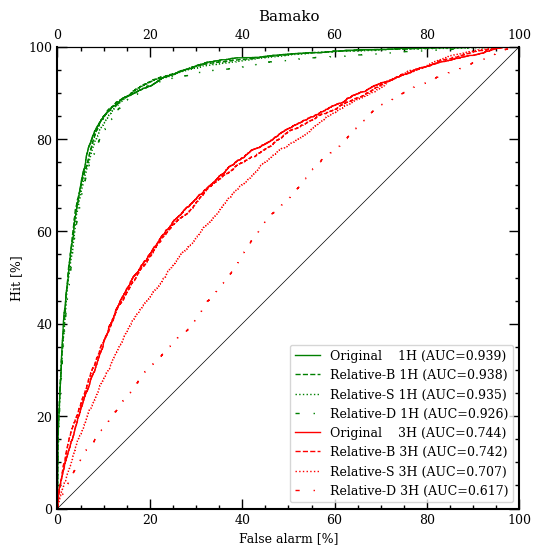

In [42]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

ax.minorticks_on()
ax.tick_params(which='major', length=7, width=1, direction='in',bottom=True, left=True, right=True)
ax.tick_params(which='minor', length=3,  width=1, direction='in',bottom=True, left=True, right=True)

for axis in ['bottom', 'left', 'right']:
	ax.spines[axis].set_linewidth(1.5) 
	ax.spines[axis].set_color('black')


ax2 = ax.secondary_xaxis('top')
ax2.minorticks_on()
ax2.tick_params(which='major', length=7, width=1, direction='in', bottom=False)
ax2.tick_params(which='minor', length=3, width=1, direction='in', bottom=False)


plot_roc(f"Original    1H (AUC={auc_normal_Bamako_t1:.3f})", y_Bamako_t1, y_pred_normal_Bamako_t1, color="green", linestyle="solid")
plot_roc(f"Relative-B 1H (AUC={auc_relative_Bamako_t1_tb:.3f})", y_Bamako_t1, y_pred_relative_Bamako_t1_tb, color="green", linestyle="dashed")
plot_roc(f"Relative-S 1H (AUC={auc_relative_Bamako_t1:.3f})", y_Bamako_t1, y_pred_relative_Bamako_t1, color="green", linestyle="dotted")
plot_roc(f"Relative-D 1H (AUC={auc_relative_Bamako_t1_td:.3f})", y_Bamako_t1, y_pred_relative_Bamako_t1_td, color="green", linestyle=loosely_dashdotdotted)


plot_roc(f"Original    3H (AUC={auc_normal_Bamako_t3:.3f})", y_Bamako_t3, y_pred_normal_Bamako_t3, color="red")
plot_roc(f"Relative-B 3H (AUC={auc_relative_Bamako_t3_tb:.3f})", y_Bamako_t3, y_pred_relative_Bamako_t3_tb, color="red", linestyle="dashed")
plot_roc(f"Relative-S 3H (AUC={auc_relative_Bamako_t3:.3f})", y_Bamako_t3, y_pred_relative_Bamako_t3, color="red", linestyle="dotted")
plot_roc(f"Relative-D 3H (AUC={auc_relative_Bamako_t3_td:.3f})", y_Bamako_t3, y_pred_relative_Bamako_t3_td, color="red", linestyle=loosely_dashdotdotted)


plt.plot(100*np.arange(0, 1.2, 0.2), 100*np.arange(0, 1.2, 0.2), color="black", linewidth=0.5)
plt.title("Bamako")

plt.legend()
plt.show()

#### Dakar

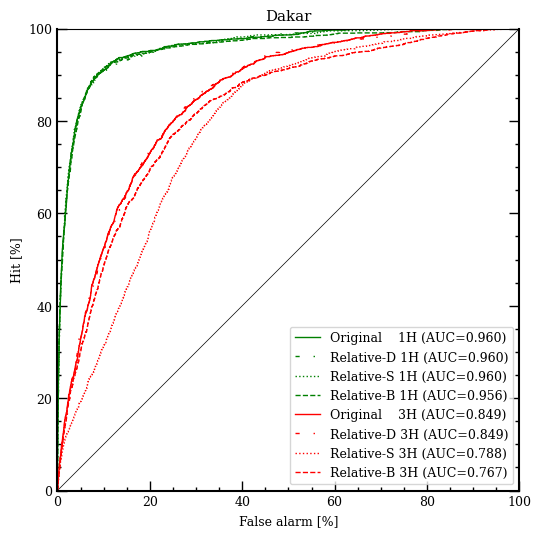

In [43]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

ax.minorticks_on()
ax.tick_params(which='major', length=7, width=1, direction='in',bottom=True, left=True, right=True)
ax.tick_params(which='minor', length=3,  width=1, direction='in',bottom=True, left=True, right=True)

for axis in ['bottom', 'left', 'right']:
	ax.spines[axis].set_linewidth(1.5) 
	ax.spines[axis].set_color('black')

plt.plot(100*np.arange(0,1.2,0.2), 100*np.arange(0,1.2,0.2), color="black", linewidth=0.5)

plot_roc(f"Original    1H (AUC={auc_normal_Dakar_t1:.3f})", y_Dakar_t1, y_pred_normal_Dakar_t1, color="green", linestyle="solid")
plot_roc(f"Relative-D 1H (AUC={auc_relative_Dakar_t1_td:.3f})", y_Dakar_t1, y_pred_relative_Dakar_t1_td, color="green", linestyle=loosely_dashdotdotted)
plot_roc(f"Relative-S 1H (AUC={auc_relative_Dakar_t1:.3f})", y_Dakar_t1, y_pred_relative_Dakar_t1, color="green", linestyle="dotted")
plot_roc(f"Relative-B 1H (AUC={auc_relative_Dakar_t1_tb:.3f})", y_Dakar_t1, y_pred_relative_Dakar_t1_tb, color="green", linestyle="dashed")


plot_roc(f"Original    3H (AUC={auc_normal_Dakar_t3:.3f})", y_Dakar_t3, y_pred_normal_Dakar_t3, color="red")
plot_roc(f"Relative-D 3H (AUC={auc_relative_Dakar_t3_td:.3f})", y_Dakar_t3, y_pred_relative_Dakar_t3_td, color="red", linestyle=loosely_dashdotdotted)
plot_roc(f"Relative-S 3H (AUC={auc_relative_Dakar_t3:.3f})", y_Dakar_t3, y_pred_relative_Dakar_t3, color="red", linestyle="dotted")
plot_roc(f"Relative-B 3H (AUC={auc_relative_Dakar_t3_tb:.3f})", y_Dakar_t3, y_pred_relative_Dakar_t1_tb, color="red", linestyle="dashed")

plt.title("Dakar")

plt.legend()
plt.show()

#### Selibaby

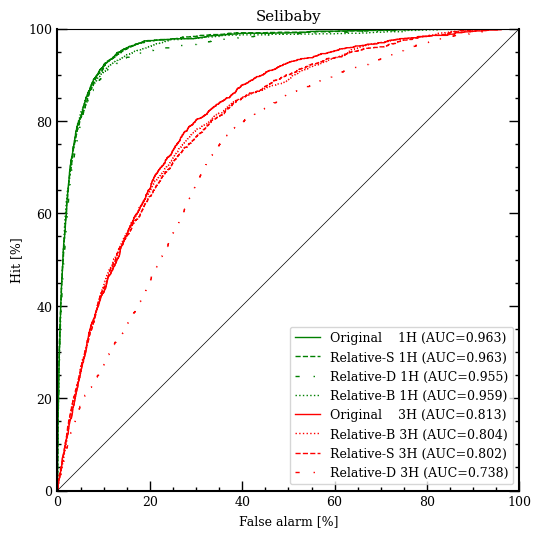

In [44]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

ax.minorticks_on()
ax.tick_params(which='major', length=7, width=1, direction='in',bottom=True, left=True, right=True)
ax.tick_params(which='minor', length=3,  width=1, direction='in',bottom=True, left=True, right=True)

for axis in ['bottom', 'left', 'right']:
	ax.spines[axis].set_linewidth(1.5) 
	ax.spines[axis].set_color('black')

plot_roc(f"Original    1H (AUC={auc_normal_Selibaby_t1:.3f})", y_Selibaby_t1, y_pred_normal_Selibaby_t1, color="green", linestyle="solid")
plot_roc(f"Relative-S 1H (AUC={auc_relative_Selibaby_t1:.3f})", y_Selibaby_t1, y_pred_relative_Selibaby_t1, color="green", linestyle="dashed")
plot_roc(f"Relative-D 1H (AUC={auc_relative_Selibaby_t1_td:.3f})", y_Selibaby_t1, y_pred_relative_Selibaby_t1_td, color="green", linestyle=loosely_dashdotdotted)
plot_roc(f"Relative-B 1H (AUC={auc_relative_Selibaby_t1_tb:.3f})", y_Selibaby_t1, y_pred_relative_Selibaby_t1_tb, color="green", linestyle="dotted")

plot_roc(f"Original    3H (AUC={auc_normal_Selibaby_t3:.3f})", y_Selibaby_t3, y_pred_normal_Selibaby_t3, color="red")
plot_roc(f"Relative-B 3H (AUC={auc_relative_Selibaby_t3_tb:.3f})", y_Selibaby_t3, y_pred_relative_Selibaby_t3_tb, color="red", linestyle="dotted")
plot_roc(f"Relative-S 3H (AUC={auc_relative_Selibaby_t3:.3f})", y_Selibaby_t3, y_pred_relative_Selibaby_t3, color="red", linestyle="dashed")
plot_roc(f"Relative-D 3H (AUC={auc_relative_Selibaby_t3_td:.3f})", y_Selibaby_t3, y_pred_relative_Selibaby_t3_td, color="red", linestyle=loosely_dashdotdotted)

plt.plot(100*np.arange(0,1.2,0.2), 100*np.arange(0,1.2,0.2), color="black", linewidth=0.5)
plt.title("Selibaby")

plt.legend()
plt.show()